
- 데이터: [KB부동산 데이터 허브](https://data.kbland.kr/) → KB 통계 → 주택가격동향조사
    - [주간 아파트 매매가격지수](https://data.kbland.kr/kbstats/wmh?tIdx=HT01&tsIdx=weekAptSalePriceInx) 전체('24년 10월 7일 기준)
    - [주간 아파트 전세가격지수](https://data.kbland.kr/kbstats/wmh?tIdx=HT01&tsIdx=weekAptRentPriceInx) 전체('24년 10월 7일 기준)

- 가격지수: 기준시점(22년 1월 10일) 대비 조사 시점(24년 10월)의 가격 비율 (주택별·지역별 가중)

# 환경설정

In [74]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


# 데이터 불러오기
두 개의 엑셀파일을 읽어와서 각각 `df_sale`, `df_rent` 변수에 할당하고, shape을 확인

In [65]:
# 코드를 작성하시오
import os
import pandas as pd
from pathlib import Path

print("현재 작업 폴더:", os.getcwd())

SALE_PATH = Path("./data/주간 아파트 매매가격지수_20260210.xlsx")
RENT_PATH = Path("./data/주간 아파트 전세가격지수_20260210.xlsx")

print("매매 파일 존재:", SALE_PATH.exists(), "|", SALE_PATH.resolve())
print("전세 파일 존재:", RENT_PATH.exists(), "|", RENT_PATH.resolve())

df_sale = pd.read_excel(SALE_PATH)
df_rent = pd.read_excel(RENT_PATH)

df_sale.shape, df_rent.shape
df_rent = pd.read_excel(RENT_PATH)

# 5) 크기 확인
df_sale.shape, df_rent.shape

현재 작업 폴더: c:\Users\Admin\hipython
매매 파일 존재: True | C:\Users\Admin\hipython\data\주간 아파트 매매가격지수_20260210.xlsx
전세 파일 존재: True | C:\Users\Admin\hipython\data\주간 아파트 전세가격지수_20260210.xlsx


((282, 899), (282, 899))

## 데이터 구조 변경
 - 컬럼은 지역명, 인덱스는 시간 정보
 - 서울 지역만 필터링
 - 집계 데이터(예. 전국, 서울, 강북14개구 등)는 제외
 - 구조 변경 결과 shape: (831, 25)
 - 변경된 데이터는 신규 변수 `df_sale_seoul`와 `df_rent_seoul`에 할당

 (예시)


 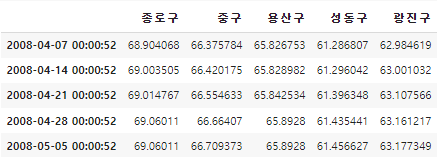

In [66]:
# 코드를 작성하시오
import pandas as pd
import numpy as np

# 서울 25개구 목록
seoul_gu = [
    "강남구","강동구","강북구","강서구","관악구","광진구","구로구","금천구","노원구","도봉구",
    "동대문구","동작구","마포구","서대문구","서초구","성동구","성북구","송파구","양천구","영등포구",
    "용산구","은평구","종로구","중구","중랑구"
]

# 1) 지역명 컬럼 이름 맞추기(첫 컬럼이 지역명인 구조)
df_sale2 = df_sale.copy()
df_rent2 = df_rent.copy()

if "지역명" not in df_sale2.columns:
    df_sale2 = df_sale2.rename(columns={df_sale2.columns[0]: "지역명"})
if "지역명" not in df_rent2.columns:
    df_rent2 = df_rent2.rename(columns={df_rent2.columns[0]: "지역명"})

# 2) 지역명 정리: '서울 ' 접두사가 있으면 제거하고, 양끝 공백 제거
df_sale2["지역명"] = df_sale2["지역명"].astype(str).str.replace("서울 ", "", regex=False).str.strip()
df_rent2["지역명"] = df_rent2["지역명"].astype(str).str.replace("서울 ", "", regex=False).str.strip()

# 3) 서울 25개구만 남기기 (집계/다른 지역 자동 제외 효과)
df_sale2 = df_sale2[df_sale2["지역명"].isin(seoul_gu)].copy()
df_rent2 = df_rent2[df_rent2["지역명"].isin(seoul_gu)].copy()

# 4) '지역명'을 인덱스로 두고, 날짜가 인덱스가 되도록 전치(transpose)
df_sale_seoul = df_sale2.set_index("지역명").T
df_rent_seoul = df_rent2.set_index("지역명").T

# 5) 인덱스(날짜) 타입 정리
df_sale_seoul.index = pd.to_datetime(df_sale_seoul.index, errors="coerce")
df_rent_seoul.index = pd.to_datetime(df_rent_seoul.index, errors="coerce")

# 6) 값 타입 정리 ('-' → NaN → 숫자)
df_sale_seoul = df_sale_seoul.replace("-", np.nan).apply(pd.to_numeric, errors="coerce")
df_rent_seoul = df_rent_seoul.replace("-", np.nan).apply(pd.to_numeric, errors="coerce")

# 7) 날짜가 NaT인 행 제거
df_sale_seoul = df_sale_seoul[~df_sale_seoul.index.isna()].sort_index()
df_rent_seoul = df_rent_seoul[~df_rent_seoul.index.isna()].sort_index()

df_sale_seoul.shape, df_rent_seoul.shape


C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\3367922972.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sale_seoul = df_sale_seoul.replace("-", np.nan).apply(pd.to_numeric, errors="coerce")
C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\3367922972.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_rent_seoul = df_rent_seoul.replace("-", np.nan).apply(pd.to_numeric, errors="coerce")


((898, 31), (898, 31))

## Long Form으로 변경
- `지역명`이 값으로 할당되도록 데이터 구조 변경
- 최종 구조 변경된 컬럼은 `지역명`, `매매가격지수`의 컬럼을 가지고 있음(전세 데이터는 `지역명`, `전세가격지수`의 컬럼을 가지고 있음)
- 변경한 데이터는 각각 `df_sale_seoul_long`, `df_rent_seoul_long` 에 할당
- 변경된 데이터의 shape: (20775, 2)

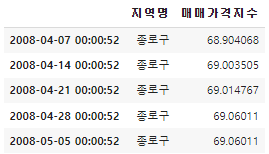

In [69]:
# 중복 컬럼 존재 여부
print("sale 중복컬럼 개수:", df_sale_seoul.columns.duplicated().sum())
print("rent 중복컬럼 개수:", df_rent_seoul.columns.duplicated().sum())

# 어떤 컬럼이 중복인지(이름) 확인
print("sale 중복 컬럼명:", df_sale_seoul.columns[df_sale_seoul.columns.duplicated()].tolist())
print("rent 중복 컬럼명:", df_rent_seoul.columns[df_rent_seoul.columns.duplicated()].tolist())


sale 중복컬럼 개수: 6
rent 중복컬럼 개수: 6
sale 중복 컬럼명: ['중구', '강서구', '중구', '중구', '중구', '중구']
rent 중복 컬럼명: ['중구', '강서구', '중구', '중구', '중구', '중구']


In [70]:
df_sale_seoul = df_sale_seoul.loc[:, ~df_sale_seoul.columns.duplicated()]
df_rent_seoul = df_rent_seoul.loc[:, ~df_rent_seoul.columns.duplicated()]

In [71]:
# 코드를 작성하시오
# wide(날짜 index, 25개구 columns) -> long(날짜 index, 지역명+지수 2개 컬럼)
df_sale_seoul_long = (
    df_sale_seoul
    .stack(future_stack=True)
    .rename("매매가격지수")
    .reset_index(level=1)
    .rename(columns={"level_1": "지역명"})
    [["지역명", "매매가격지수"]]
)

df_rent_seoul_long = (
    df_rent_seoul
    .stack(future_stack=True)
    .rename("전세가격지수")
    .reset_index(level=1)
    .rename(columns={"level_1": "지역명"})
    [["지역명", "전세가격지수"]]
)

df_sale_seoul_long.shape, df_rent_seoul_long.shape

((22450, 2), (22450, 2))

# 데이터 시각화
- 전처리가 수행된 데이터 프레임  `df_sale_seoul`와 `df_rent_seoul` 또는 `df_sale_seoul_long`, `df_rent_seoul_long`을 사용하여 데이터 시각화 수행
- (예시)
    - `강남구`의 날짜별 `매매가격지수`, `전세가격지수` 시각화
    - `강남구`의 `매매가격지수`, `전세가격지수` 상관관계 시각화
    - `매매가격지수`와 `전세가격지수`의 차이가 가장 큰(적은) 지역을 판단하고, 해당 지역에 가격지수를 시각화
    - 연도별 데이터 집계하여 시각화 등
    
- 필요 시 추가 데이터 전처리 수행    

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 폰트(나눔고딕)을 기본 폰트로 사용하도록 설정
plt.rcParams["font.family"] = 'NanumGothic'

# 그래프에서 마이너스 폰트 깨지는 문제 해결
mpl.rcParams['axes.unicode_minus'] = False

### 강남구의 날짜별 매매가격지수, 전세가격지수 시각화

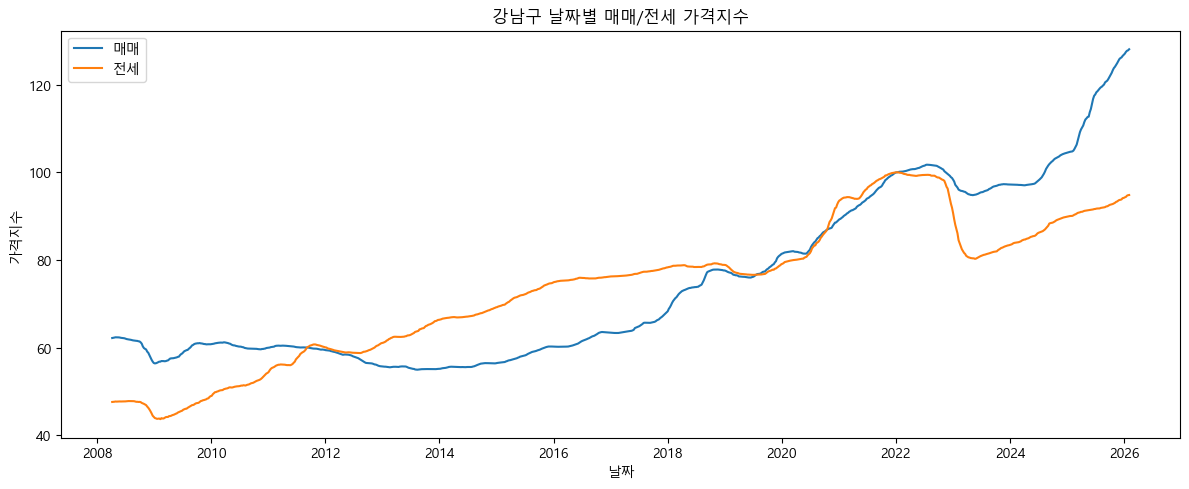

In [75]:
# 코드를 작성하시오
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams["font.family"] = "Malgun Gothic"   # ← 여기만 변경
mpl.rcParams["axes.unicode_minus"] = False

target = "강남구"

plot_df = pd.DataFrame({
    "날짜": df_sale_seoul.index,
    "매매가격지수": df_sale_seoul[target].values,
    "전세가격지수": df_rent_seoul[target].reindex(df_sale_seoul.index).values
}).dropna()

plt.figure(figsize=(12,5))
sns.lineplot(data=plot_df, x="날짜", y="매매가격지수", label="매매")
sns.lineplot(data=plot_df, x="날짜", y="전세가격지수", label="전세")
plt.title(f"{target} 날짜별 매매/전세 가격지수")
plt.xlabel("날짜"); plt.ylabel("가격지수")
plt.legend()
plt.tight_layout()
plt.show()


### 강남구의 매매가격지수, 전세가격지수 상관관계 시각화

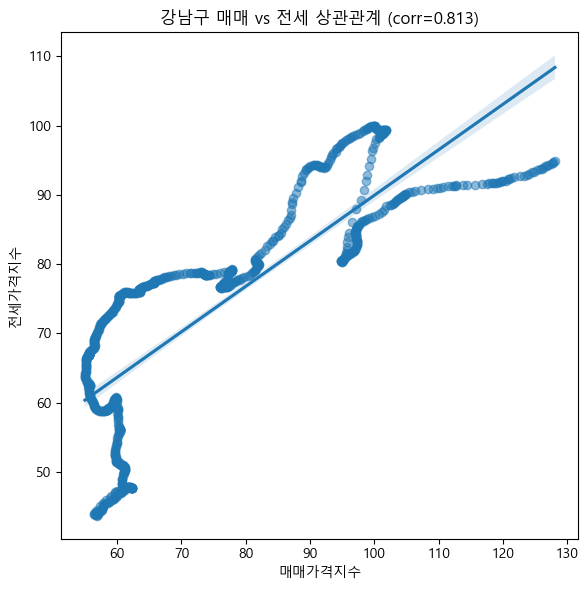

In [76]:
# 코드를 작성하시오
target = "강남구"

corr_df = pd.DataFrame({
    "매매가격지수": df_sale_seoul[target],
    "전세가격지수": df_rent_seoul[target]
}).dropna()

plt.figure(figsize=(6,6))
sns.regplot(data=corr_df, x="매매가격지수", y="전세가격지수", scatter_kws={"alpha":0.5})
plt.title(f"{target} 매매 vs 전세 상관관계 (corr={corr_df.corr().iloc[0,1]:.3f})")
plt.tight_layout()
plt.show()


### 매매가격지수와 전세가격지수의 차이가 가장 큰(or 적은) 지역을 판단하고, 해당 지역에 가격지수를 시각화

평균 (매매-전세) 차이 가장 큰 구: 송파구 | 평균: 2.6225534655720377
평균 (매매-전세) 차이 가장 작은 구: 노원구 | 평균: -6.262704006057859


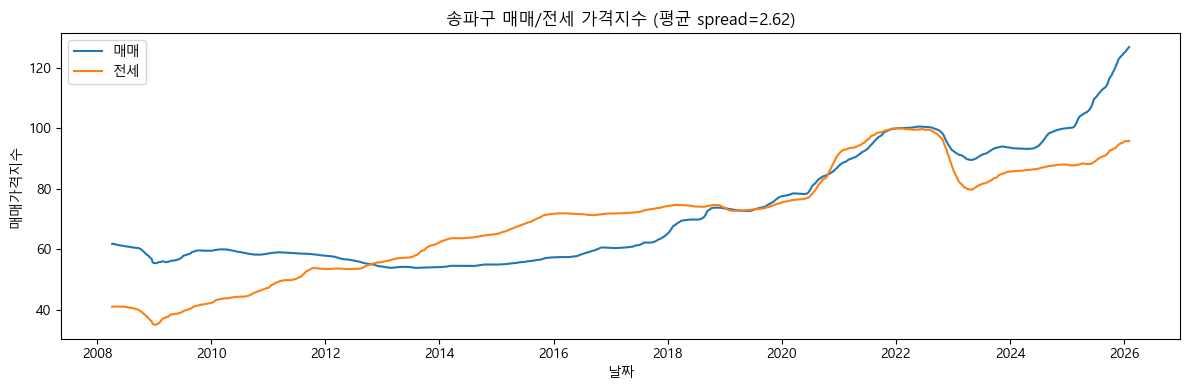

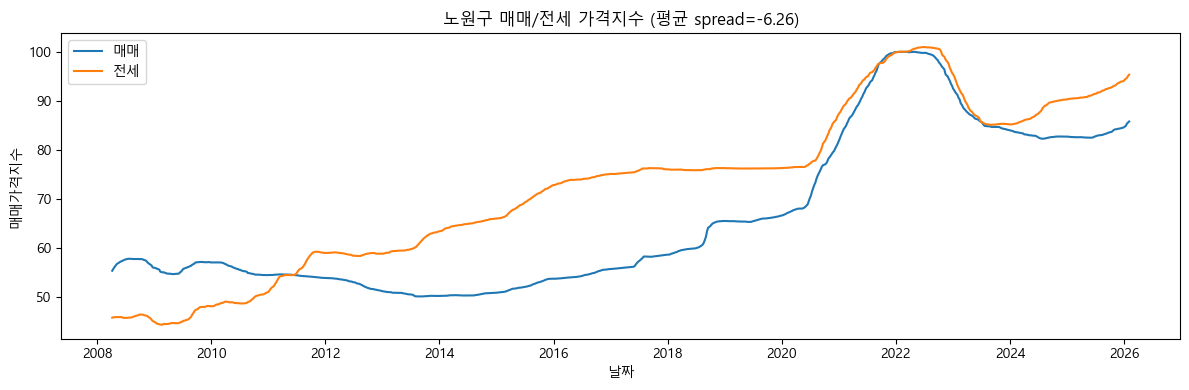

In [77]:
# 코드를 작성하시오
# 같은 날짜에서 (매매 - 전세) 차이(spread)를 구해서,
# 평균 spread가 가장 큰/작은 구를 찾고, 해당 구의 시계열을 그린다.

# 날짜를 맞춘 뒤 spread 계산
common_idx = df_sale_seoul.index.intersection(df_rent_seoul.index)
spread = df_sale_seoul.loc[common_idx] - df_rent_seoul.loc[common_idx]

mean_spread = spread.mean().sort_values(ascending=False)
max_gu = mean_spread.index[0]
min_gu = mean_spread.index[-1]

print("평균 (매매-전세) 차이 가장 큰 구:", max_gu, "| 평균:", mean_spread.iloc[0])
print("평균 (매매-전세) 차이 가장 작은 구:", min_gu, "| 평균:", mean_spread.iloc[-1])

def plot_two_index(gu):
    tmp = pd.DataFrame({
        "날짜": common_idx,
        "매매가격지수": df_sale_seoul.loc[common_idx, gu].values,
        "전세가격지수": df_rent_seoul.loc[common_idx, gu].values
    }).dropna()
    plt.figure(figsize=(12,4))
    sns.lineplot(data=tmp, x="날짜", y="매매가격지수", label="매매")
    sns.lineplot(data=tmp, x="날짜", y="전세가격지수", label="전세")
    plt.title(f"{gu} 매매/전세 가격지수 (평균 spread={mean_spread[gu]:.2f})")
    plt.tight_layout()
    plt.show()

plot_two_index(max_gu)
plot_two_index(min_gu)


### '강남구'의 매매가격지수변동률과 전세가격지수 변동률을 구하고, 시각화

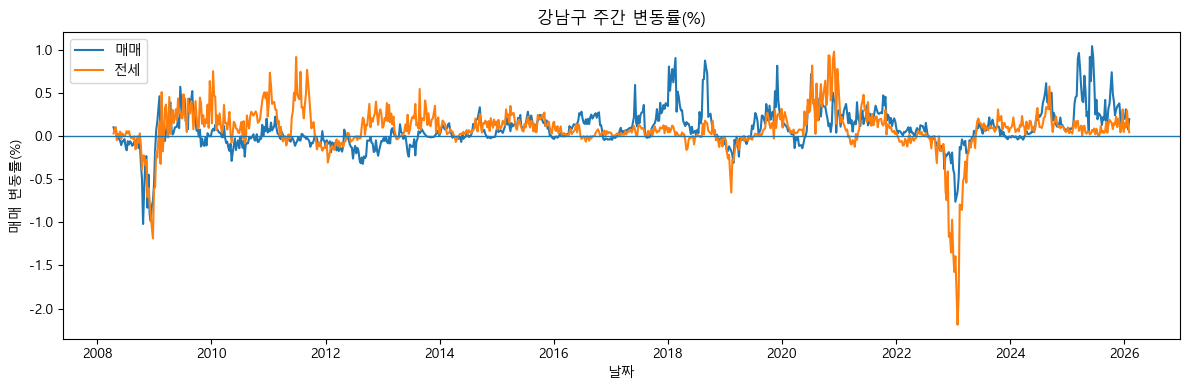

In [78]:
# 코드를 작성하시오
# 주간 변동률(%) 계산: pct_change * 100
target = "강남구"

sale_ret = df_sale_seoul[target].pct_change() * 100
rent_ret = df_rent_seoul[target].pct_change() * 100

ret_df = pd.DataFrame({
    "날짜": df_sale_seoul.index,
    "매매 변동률(%)": sale_ret.values,
    "전세 변동률(%)": rent_ret.reindex(df_sale_seoul.index).values
}).dropna()

plt.figure(figsize=(12,4))
sns.lineplot(data=ret_df, x="날짜", y="매매 변동률(%)", label="매매")
sns.lineplot(data=ret_df, x="날짜", y="전세 변동률(%)", label="전세")
plt.axhline(0, linewidth=1)
plt.title(f"{target} 주간 변동률(%)")
plt.tight_layout()
plt.show()


### 서울 지역별 특정 시점(예. 24년 10월) 기준 전세가격지수 변동률을 히트맵으로 시각화

In [79]:
import folium
from folium.plugins import HeatMap

# 서울시 지역구별 위경도 및 인구수를 데이터프레임으로 생성
data = {
    'district': ['강남구', '강동구', '강서구', '관악구', '광진구', '구로구',
                 '금천구', '노원구', '도봉구', '동대문구', '동작구', '마포구',
                 '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구',
                 '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구'],
    'latitude': [37.4979, 37.5307, 37.5502, 37.4783, 37.5407, 37.4950,
                 37.4574, 37.6529, 37.6692, 37.5743, 37.5125, 37.5547,
                 37.5772, 37.4845, 37.5636, 37.5894, 37.5155, 37.5110,
                 37.5260, 37.5326, 37.6063, 37.5700, 37.5636, 37.6016],
    'longitude': [127.0276, 127.1237, 126.8499, 126.9515, 127.0823, 126.8824,
                  126.8956, 127.0771, 127.0335, 127.0395, 126.9810, 126.9067,
                  126.9368, 127.0322, 127.0425, 127.0117, 127.1050, 126.8642,
                  126.9035, 126.9947, 126.9280, 126.9800, 126.9970, 127.0959],
}

# 데이터프레임 생성
seoul_GIS = pd.DataFrame(data)

In [84]:
import pandas as pd
import numpy as np

# 1) 기준일/비교일
base_date = df_rent_seoul.index.min()
target_date = df_rent_seoul.index.max()

# 2) 구별 전세 변동률(%)
rent_change_pct = (df_rent_seoul.loc[target_date] / df_rent_seoul.loc[base_date] - 1) * 100
rent_change_pct = rent_change_pct.rename("rent_change_pct")

# ※ 여기서 인덱스 이름이 '지역명'일 수도, None일 수도 있어요.
#    무조건 컬럼명 'district'로 통일
rent_change_pct = rent_change_pct.reset_index()
rent_change_pct.columns = ["district", "rent_change_pct"]

# 3) 위경도 데이터프레임 만들기 (앞에서 만든 data 사용)
df_coords = pd.DataFrame(data)

# 4) df_coords에도 구 이름 컬럼을 district로 통일
#    (실습용: 후보 중 하나를 찾아서 district로 바꾸기)
name_candidates = ["district", "구", "지역명", "name"]
name_col = None
for c in name_candidates:
    if c in df_coords.columns:
        name_col = c
        break

if name_col is None:
    raise ValueError(f"df_coords에 구 이름 컬럼이 없습니다. df_coords.columns={df_coords.columns.tolist()}")

df_coords = df_coords.rename(columns={name_col: "district"})

# 5) 위도/경도 컬럼도 통일(lat, lon)
lat_candidates = ["lat", "latitude", "위도"]
lon_candidates = ["lon", "lng", "longitude", "경도"]

lat_col = next((c for c in lat_candidates if c in df_coords.columns), None)
lon_col = next((c for c in lon_candidates if c in df_coords.columns), None)

if lat_col is None or lon_col is None:
    raise ValueError(f"위도/경도 컬럼을 찾지 못했습니다. df_coords.columns={df_coords.columns.tolist()}")

df_coords = df_coords.rename(columns={lat_col: "lat", lon_col: "lon"})

# 6) 병합 (여기서 heat_df가 생성됨)
heat_df = df_coords.merge(rent_change_pct, on="district", how="left")

print("기준일:", base_date.date(), "| 비교일:", target_date.date())
print("heat_df 컬럼:", heat_df.columns.tolist())
heat_df.head()


기준일: 2008-04-07 | 비교일: 2026-02-02
heat_df 컬럼: ['district', 'lat', 'lon', 'rent_change_pct']


,district,lat,lon,rent_change_pct
0,강남구,37.4979,127.0276,99.086109
1,강동구,37.5307,127.1237,93.956513
2,강서구,37.5502,126.8499,140.189847
3,관악구,37.4783,126.9515,99.810094
4,광진구,37.5407,127.0823,120.734424


In [85]:
# 코드를 작성하시오
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[37.5665, 126.9780], zoom_start=11)

heat_data = heat_df[["lat", "lon", "rent_change_pct"]].dropna().values.tolist()
HeatMap(heat_data, radius=18, blur=12).add_to(m)

for _, r in heat_df.dropna(subset=["rent_change_pct"]).iterrows():
    folium.CircleMarker(
        location=[r["lat"], r["lon"]],
        radius=6,
        popup=f'{r["district"]}: {r["rent_change_pct"]:.1f}%',
        fill=True
    ).add_to(m)

m
